# 🔧 Machine Failure Prediction
**Dataset:** AI4I 2020 Predictive Maintenance Dataset  
**Goal:** Predict machine failures using sensor and operational data  
**Approach:** EDA → Feature Engineering → Model Training → Imbalance Handling

---

## 1. Imports & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

# List available input files (Kaggle environment)
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

---
## 2. Load Data

In [2]:
df = pd.read_csv("ai4i2020.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [4]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


### 3.2 Target Variable — Class Imbalance Check

In [5]:
failure_count = (df['Machine failure'] == 1).sum()
total = len(df)
print(f"Total records     : {total}")
print(f"Failure cases     : {failure_count}")
print(f"Non-failure cases : {total - failure_count}")
print(f"Failure rate      : {failure_count / total:.2%}")

Total records     : 10000
Failure cases     : 339
Non-failure cases : 9661
Failure rate      : 3.39%


### 3.3 Univariate Analysis — Machine Type (Feature: `Type`)

The dataset contains 3 machine quality variants:
- **L** — Low quality (majority)
- **M** — Medium quality
- **H** — High quality (minority)

Machine type distribution:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


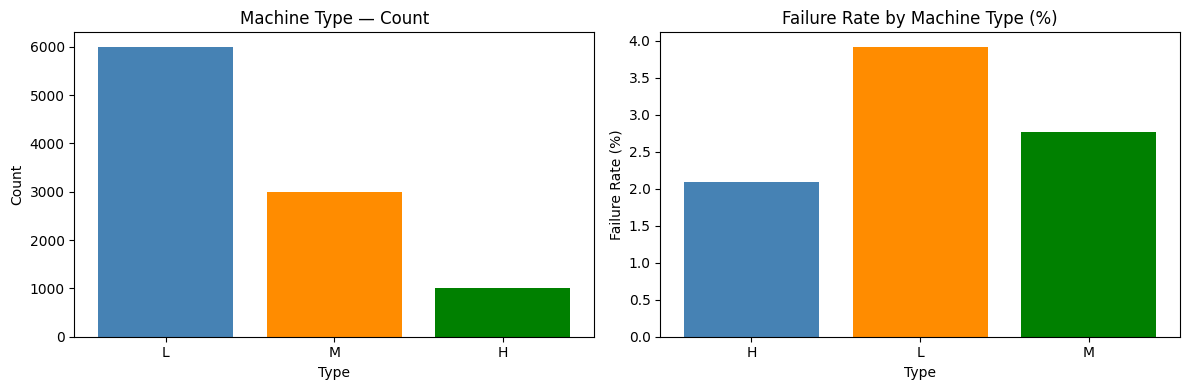

In [6]:
type_counts = df['Type'].value_counts()
print("Machine type distribution:")
print(type_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart — count
axes[0].bar(type_counts.index, type_counts.values, color=['steelblue', 'darkorange', 'green'])
axes[0].set_title('Machine Type — Count')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')

# Failure rate by type
failure_rate = df.groupby('Type')['Machine failure'].mean() * 100
axes[1].bar(failure_rate.index, failure_rate.values, color=['steelblue', 'darkorange', 'green'])
axes[1].set_title('Failure Rate by Machine Type (%)')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Failure Rate (%)')

plt.tight_layout()
plt.show()

### 3.4 Feature Correlation with Target

In [7]:
# Drop non-informative identifier columns and individual failure sub-types
# (sub-types are leakage features — they directly encode the target)
df = df.drop(columns=['Product ID', 'UDI', 'HDF', 'OSF', 'PWF', 'TWF', 'RNF'])

corr = df.corr(numeric_only=True)['Machine failure'].sort_values(ascending=False)
print("Correlation with Machine Failure:")
print(corr)

Correlation with Machine Failure:
Machine failure            1.000000
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64


### 3.5 Torque Analysis

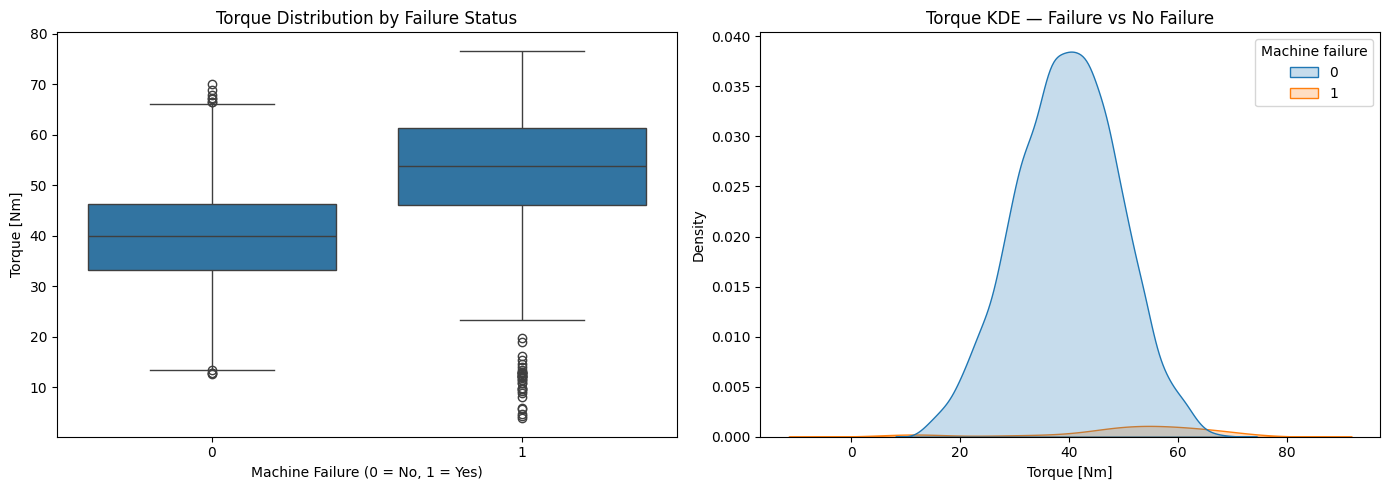

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot — Torque vs Failure
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df, ax=axes[0])
axes[0].set_title('Torque Distribution by Failure Status')
axes[0].set_xlabel('Machine Failure (0 = No, 1 = Yes)')

# KDE plot — Torque distribution per class
sns.kdeplot(data=df, x='Torque [Nm]', hue='Machine failure', fill=True, ax=axes[1])
axes[1].set_title('Torque KDE — Failure vs No Failure')

plt.tight_layout()
plt.show()

### 3.6(a) Torque vs rotating speed  (Scatter)

Text(0.5, 1.0, 'Scatter plot showing relation to speed and torque')

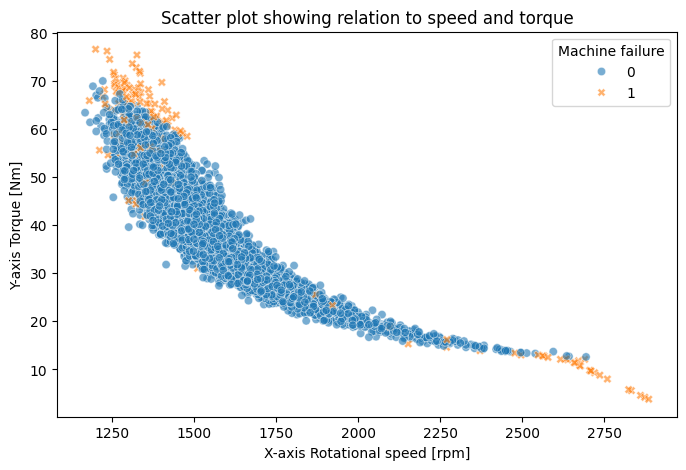

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Rotational speed [rpm]', y='Torque [Nm]', hue='Machine failure', style='Machine failure',alpha=0.6)
# Add labels and title
plt.xlabel("X-axis Rotational speed [rpm]")
plt.ylabel("Y-axis Torque [Nm]")
plt.title("Scatter plot showing relation to speed and torque")


### 3.6(b) Torque vs Tool Wear (Scatter)

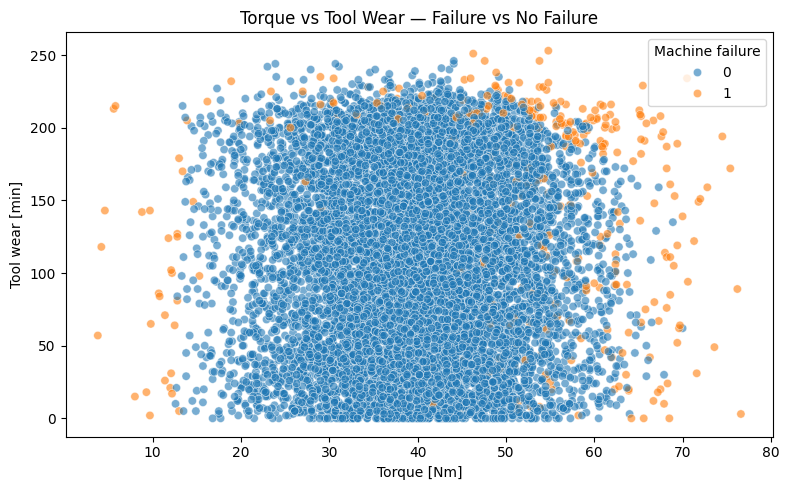

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Torque [Nm]', y='Tool wear [min]', hue='Machine failure', alpha=0.6)
plt.title('Torque vs Tool Wear — Failure vs No Failure')
plt.tight_layout()
plt.show()

---
## 4. Feature Engineering & Preprocessing

In [11]:
print("Columns after dropping leakage features:")
print(df.columns.tolist())
df.head()

Columns after dropping leakage features:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [12]:
# Separate features and target
X = df.drop(columns=['Machine failure'])
y = df['Machine failure']

# Train-test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")

Train size : (8000, 6)
Test size  : (2000, 6)


In [13]:
# One-Hot Encode the categorical 'Type' column
ohe = OneHotEncoder(sparse_output=False, drop='first')

X_train_ohe = pd.DataFrame(
    ohe.fit_transform(X_train[['Type']]),
    columns=ohe.get_feature_names_out(['Type']),
    index=X_train.index
)
X_test_ohe = pd.DataFrame(
    ohe.transform(X_test[['Type']]),
    columns=ohe.get_feature_names_out(['Type']),
    index=X_test.index
)

X_train_enc = pd.concat([X_train_ohe, X_train.drop(columns='Type')], axis=1)
X_test_enc  = pd.concat([X_test_ohe,  X_test.drop(columns='Type')],  axis=1)

print(f"Encoded train shape: {X_train_enc.shape}")
X_train_enc.head()

Encoded train shape: (8000, 7)


,Type_L,Type_M,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
4058,0.0,1.0,302.0,310.9,1456,47.2,54
1221,0.0,1.0,297.0,308.3,1399,46.4,132
6895,0.0,1.0,301.0,311.6,1357,45.6,137
9863,1.0,0.0,298.9,309.8,1411,56.3,84
8711,1.0,0.0,297.1,308.5,1733,28.7,50


---
## 5. Baseline Model — Random Forest

In [14]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_enc, y_train)

y_pred = rf.predict(X_test_enc)

print("=== Random Forest — Default Threshold (0.5) ===")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

=== Random Forest — Default Threshold (0.5) ===
[[1928    4]
 [  28   40]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.91      0.59      0.71        68

    accuracy                           0.98      2000
   macro avg       0.95      0.79      0.85      2000
weighted avg       0.98      0.98      0.98      2000



### 5.1 Feature Importances

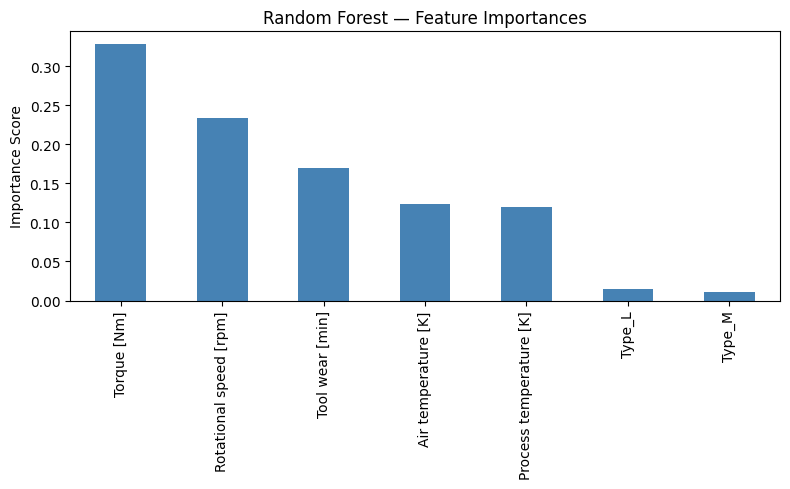

In [15]:
importances = pd.Series(rf.feature_importances_, index=X_train_enc.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='bar', color='steelblue')
plt.title('Random Forest — Feature Importances')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

### 5.2 Threshold Tuning

Since machine failures are costly to miss, we lower the decision threshold to **boost recall** at the expense of precision.

In [16]:
y_prob = rf.predict_proba(X_test_enc)[:, 1]
y_pred_tuned = (y_prob > 0.3).astype(int)

print("=== Random Forest — Tuned Threshold (0.3) ===")
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

=== Random Forest — Tuned Threshold (0.3) ===
[[1911   21]
 [  17   51]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.71      0.75      0.73        68

    accuracy                           0.98      2000
   macro avg       0.85      0.87      0.86      2000
weighted avg       0.98      0.98      0.98      2000



---
## 6. Handling Class Imbalance

The dataset is heavily imbalanced (~3.4% failure rate). We explore two strategies:

| Strategy | Description |
|---|---|
| **SMOTE** | Synthetic oversampling of minority class |
| **Balanced Random Forest** | Built-in undersampling per tree |

> **Why not simple undersampling?** It risks losing valuable majority-class patterns and introduces sampling bias.

### 6.1 SMOTE — Synthetic Minority Oversampling

In [17]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_enc, y_train)

print(f"Before SMOTE — class distribution:\n{y_train.value_counts()}")
print(f"\nAfter SMOTE  — class distribution:\n{pd.Series(y_resampled).value_counts()}")

Before SMOTE — class distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

After SMOTE  — class distribution:
Machine failure
0    7729
1    7729
Name: count, dtype: int64


In [18]:
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_resampled, y_resampled)

y_pred_smote = rf_smote.predict(X_test_enc)

print("=== RF + SMOTE — Default Threshold ===")
print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

=== RF + SMOTE — Default Threshold ===
[[1881   51]
 [  22   46]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.47      0.68      0.56        68

    accuracy                           0.96      2000
   macro avg       0.73      0.83      0.77      2000
weighted avg       0.97      0.96      0.97      2000



In [19]:
y_prob_smote = rf_smote.predict_proba(X_test_enc)[:, 1]
y_pred_smote_tuned = (y_prob_smote > 0.2).astype(int)

print("=== RF + SMOTE — Tuned Threshold (0.2) ===")
print(confusion_matrix(y_test, y_pred_smote_tuned))
print(classification_report(y_test, y_pred_smote_tuned))

=== RF + SMOTE — Tuned Threshold (0.2) ===
[[1807  125]
 [   8   60]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.96      1932
           1       0.32      0.88      0.47        68

    accuracy                           0.93      2000
   macro avg       0.66      0.91      0.72      2000
weighted avg       0.97      0.93      0.95      2000



> **Observation:** SMOTE does not significantly improve model performance over baseline. Tree-based models can implicitly handle synthetic samples, and the gain is marginal here.

### 6.2 Balanced Random Forest (Ensemble)

In [20]:
brf = BalancedRandomForestClassifier(random_state=42)
brf.fit(X_train_enc, y_train)

y_pred_brf = brf.predict(X_test_enc)

print("=== Balanced Random Forest ===")
print(confusion_matrix(y_test, y_pred_brf))
print(classification_report(y_test, y_pred_brf))

=== Balanced Random Forest ===
[[1769  163]
 [   6   62]]
              precision    recall  f1-score   support

           0       1.00      0.92      0.95      1932
           1       0.28      0.91      0.42        68

    accuracy                           0.92      2000
   macro avg       0.64      0.91      0.69      2000
weighted avg       0.97      0.92      0.94      2000



> **Observation:** The Balanced RF aggressively prioritises failure detection — achieving ~0.91 recall at the cost of low precision (~0.28). This is the most sensitive model in the set.

---
## 7. Model Comparison & Business Recommendation

### Summary Table

| Model | Recall (Failure) | Precision (Failure) | Notes |
|---|---|---|---|
| RF (threshold 0.5) | Moderate | High | Conservative — misses failures |
| RF (threshold 0.3) | ~0.74 | ~0.74 | Balanced trade-off |
| RF + SMOTE | Similar to baseline | Similar | Marginal gain |
| Balanced RF | ~0.91 | ~0.28 | Catches almost all failures |

### Business Context

The right model depends on the cost structure of the operation:

- **Machines are expensive** → missing a failure is catastrophic → **prioritise Recall**
- **Maintenance teams are limited** → false alarms are also costly → **Precision matters too**

### Recommended: 3-Level Risk Alarm System

Rather than deploying a single model, use all three in a tiered alert system:

1. 🔴 **RED ALERT** — Balanced RF flags it → Immediate inspection required  
2. 🟠 **ORANGE ALERT** — RF (threshold 0.3) also flags it → High-priority check  
3. 🟡 **YELLOW ALERT** — Only baseline RF flags it → Schedule routine review  

This preserves both high recall and actionable precision without forcing a single cut-off.

In [21]:
## Preserv important models 

import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(rf,    'models/rf_balanced.pkl')
joblib.dump(rf_smote, 'models/rf_high_recall.pkl')
joblib.dump(ohe,            'models/preprocessor.pkl')


['models/preprocessor.pkl']